In [35]:
!pip -q install pygame torch numpy

import os, math, random, argparse
from collections import deque, namedtuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

In [36]:
# Cell 2: Global Config

# 游戏环境尺寸（state中会归一化到[0,1]）
W, H = 720, 520

# Agent (Cat) settings
CAT_R = 14              # cat radius
CAT_SPEED = 4.0         # cat movement speed

# Object settings
FISH_R = 10
TRAP_R = 12
N_TRAPS = 5

# Episode length
EPISODE_MAX_STEPS = 900

# -------- RL (Q-learning / DQN) settings --------

MODEL_PATH = "dqn_catfish.pt"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Transition tuple for replay buffer (experience replay)
Transition = namedtuple("Transition", ("state", "action", "reward", "next_state", "done"))

In [37]:
# Cell 3: Helper Functions

def clamp(v, lo, hi):
    return lo if v < lo else hi if v > hi else v

def dist(ax, ay, bx, by):
    return math.hypot(ax - bx, ay - by)

In [38]:
# Cell 4: Environment (Cat Eats Fish)

# This environment defines:
# - State Space (状态空间)
# - Action Space (动作空间)
# - Reward Function (奖励函数)
# which are required by the assignment rubric. :contentReference[oaicite:3]{index=3}

class CatFishEnv:
    """
    Continuous 2D arena.
    Cat collects fish (positive reward) and avoids traps (negative reward).
    """

    def __init__(self, n_traps=N_TRAPS):
        self.n_traps = n_traps
        self.reset()

    # -------- Action Space --------
    # Discrete actions: 0 up,1 down,2 left,3 right,4 stay
    @property
    def n_actions(self):
        return 5

    # -------- State Space --------
    # State vector (11 dims):
    # [cat_x, cat_y, cat_vx, cat_vy,
    #  fish_dx, fish_dy, fish_dist,
    #  nearest_trap_dx, nearest_trap_dy, nearest_trap_dist,
    #  step_frac]
    @property
    def state_dim(self):
        return 11

    def reset(self):
        # Initialize cat position (center)
        self.cx = W * 0.5
        self.cy = H * 0.5
        self.cvx = 0.0
        self.cvy = 0.0

        # Spawn fish and traps
        self.fx, self.fy = self._rand_pos(margin=60)
        self.traps = []
        for _ in range(self.n_traps):
            tx, ty = self._rand_pos(margin=60)
            self.traps.append([tx, ty])

        self.steps = 0
        self.score = 0
        self.last_action = 4

        # small memory for "stuck" penalty
        self._last_pos = deque(maxlen=20)
        self._last_pos.append((self.cx, self.cy))

        return self._get_state()

    def _rand_pos(self, margin=40):
        return (random.uniform(margin, W - margin),
                random.uniform(margin, H - margin))

    @staticmethod
    def action_to_vec(a):
        # Mapping action id -> movement direction
        if a == 0: return (0.0, -1.0)
        if a == 1: return (0.0, 1.0)
        if a == 2: return (-1.0, 0.0)
        if a == 3: return (1.0, 0.0)
        return (0.0, 0.0)

    def step(self, action):
        """
        One environment step:
        1) Apply action to move the cat
        2) Compute reward based on event & shaping
        3) Return next_state, reward, done
        """
        self.steps += 1
        self.last_action = int(action)

        # 1) Move cat
        dx, dy = self.action_to_vec(action)
        self.cvx, self.cvy = dx * CAT_SPEED, dy * CAT_SPEED
        self.cx += self.cvx
        self.cy += self.cvy

        # Clamp to arena boundary
        self.cx = clamp(self.cx, CAT_R, W - CAT_R)
        self.cy = clamp(self.cy, CAT_R, H - CAT_R)
        self._last_pos.append((self.cx, self.cy))

        # 2) Reward function (奖励函数)
        # Reward shaping helps Q-learning learn faster.
        reward = 0.0
        done = False

        # (A) survival reward: encourage staying alive
        reward += 0.03

        # (B) step penalty: encourage efficiency (not wandering)
        reward -= 0.005

        # (C) edge penalty: discourage camping near boundary
        edge_margin = 30
        if self.cx < edge_margin or self.cx > W - edge_margin or self.cy < edge_margin or self.cy > H - edge_margin:
            reward -= 0.02

        # (D) fish distance shaping: closer to fish => better
        fish_d = dist(self.cx, self.cy, self.fx, self.fy)
        fish_dist_norm = fish_d / math.hypot(W, H)
        reward += (0.04 * (1.0 - fish_dist_norm))

        # (E) trap avoidance shaping: farther from nearest trap => better
        ntx, nty, trap_d = self._nearest_trap()
        trap_dist_norm = trap_d / math.hypot(W, H)
        reward += (0.03 * trap_dist_norm)

        # (F) eat fish: major positive reward
        if fish_d <= (CAT_R + FISH_R):
            self.score += 1
            reward += 3.0
            # Respawn fish at new location
            self.fx, self.fy = self._rand_pos(margin=60)

        # (G) hit trap: major negative reward & episode ends
        if self._hit_trap():
            reward -= 8.0
            done = True

        # (H) time limit: prevent infinite episode
        if self.steps >= EPISODE_MAX_STEPS:
            done = True

        # (I) stuck penalty: if hardly moved in last ~20 steps
        if len(self._last_pos) == self._last_pos.maxlen:
            moved = dist(self._last_pos[0][0], self._last_pos[0][1],
                         self._last_pos[-1][0], self._last_pos[-1][1])
            if moved < 6.0:
                reward -= 0.03

        return self._get_state(), float(reward), bool(done)

    def _nearest_trap(self):
        best = (None, None, 1e9)
        for tx, ty in self.traps:
            d = dist(self.cx, self.cy, tx, ty)
            if d < best[2]:
                best = (tx, ty, d)
        return best

    def _hit_trap(self):
        for tx, ty in self.traps:
            if dist(self.cx, self.cy, tx, ty) <= (CAT_R + TRAP_R):
                return True
        return False

    def _get_state(self):
        """
        Build normalized state vector.
        IMPORTANT: normalization makes NN training stable.
        """
        cat_x = self.cx / W
        cat_y = self.cy / H
        cat_vx = self.cvx / CAT_SPEED if CAT_SPEED > 0 else 0.0
        cat_vy = self.cvy / CAT_SPEED if CAT_SPEED > 0 else 0.0

        fish_dx = (self.fx - self.cx) / W
        fish_dy = (self.fy - self.cy) / H
        fish_d = dist(self.cx, self.cy, self.fx, self.fy) / math.hypot(W, H)

        ntx, nty, td = self._nearest_trap()
        trap_dx = (ntx - self.cx) / W
        trap_dy = (nty - self.cy) / H
        trap_d = td / math.hypot(W, H)

        step_frac = self.steps / EPISODE_MAX_STEPS

        return np.array([
            cat_x, cat_y, cat_vx, cat_vy,
            fish_dx, fish_dy, fish_d,
            trap_dx, trap_dy, trap_d,
            step_frac
        ], dtype=np.float32)

In [39]:
# Cell 5: Replay Buffer

# Experience Replay helps stabilize DQN training.

class ReplayBuffer:
    def __init__(self, capacity=80_000):
        self.buf = deque(maxlen=capacity)

    def push(self, *args):
        self.buf.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buf, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buf)

In [40]:
# Cell 6: Q Network

# Neural network approximates Q(s, a).
# For each state input, it outputs Q-values for all actions.

class QNet(nn.Module):
    def __init__(self, state_dim, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
        )

    def forward(self, x):
        return self.net(x)

In [41]:
# Cell 7: DQN Agent (Q-learning)

# This is Q-learning with function approximation (Deep Q-learning / DQN).


class DQNAgent:
    def __init__(
        self,
        state_dim,
        n_actions,
        lr=1e-3,           # learning rate α
        gamma=0.95,        # discount factor γ
        eps_start=1.0,
        eps_end=0.05,
        eps_decay_steps=90_000,
        batch_size=64,
        target_sync=1000,
    ):
        self.state_dim = state_dim
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_sync = target_sync

        self.policy_net = QNet(state_dim, n_actions).to(DEVICE)
        self.target_net = QNet(state_dim, n_actions).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # optimizer uses lr = alpha
        self.optim = optim.Adam(self.policy_net.parameters(), lr=lr)
        self.loss_fn = nn.SmoothL1Loss()

        self.replay = ReplayBuffer()
        self.steps_done = 0

        # epsilon schedule for epsilon-greedy
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay_steps = eps_decay_steps

    def epsilon(self):
        # linear decay from eps_start -> eps_end
        t = min(self.steps_done, self.eps_decay_steps)
        return self.eps_start + (self.eps_end - self.eps_start) * (t / self.eps_decay_steps)

    @torch.no_grad()
    def act(self, state, greedy=False):
        """
        epsilon-greedy:
        - with prob epsilon: explore random action
        - else: exploit best action from Q-network
        """
        self.steps_done += 1
        eps = self.epsilon()

        if greedy or random.random() > eps:
            s = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            q = self.policy_net(s)
            return int(q.argmax(dim=1).item()), eps
        else:
            return random.randrange(self.n_actions), eps

    def learn(self):
        """
        Q-learning update (DQN):
        target = r + gamma * max_a' Q_target(s', a') * (1-done)
        loss = Huber(Q_policy(s,a), target)
        """
        if len(self.replay) < self.batch_size:
            return None

        batch = self.replay.sample(self.batch_size)

        states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=DEVICE)
        actions = torch.tensor(batch.action, dtype=torch.int64, device=DEVICE).unsqueeze(1)
        rewards = torch.tensor(batch.reward, dtype=torch.float32, device=DEVICE).unsqueeze(1)
        next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=DEVICE)
        dones = torch.tensor(batch.done, dtype=torch.float32, device=DEVICE).unsqueeze(1)

        # Q(s,a) from policy net
        q_sa = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            q_next = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            target = rewards + self.gamma * q_next * (1.0 - dones)

        loss = self.loss_fn(q_sa, target)

        self.optim.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 10.0)
        self.optim.step()

        # sync target network periodically
        if self.steps_done % self.target_sync == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        return float(loss.item())

    def save(self, path=MODEL_PATH):
        torch.save(self.policy_net.state_dict(), path)

    def load(self, path=MODEL_PATH):
        self.policy_net.load_state_dict(torch.load(path, map_location=DEVICE))
        self.target_net.load_state_dict(self.policy_net.state_dict())

In [42]:
# Cell 8: Training Loop


def train(episodes=1200, save_every=50):
    env = CatFishEnv()
    agent = DQNAgent(
        state_dim=env.state_dim,
        n_actions=env.n_actions,
        lr=1e-3,         # alpha
        gamma=0.95,      # gamma
        eps_start=1.0,
        eps_end=0.05,
        eps_decay_steps=90_000,
        batch_size=64,
        target_sync=900
    )

    best = -1e9
    history = []  # store (ep, ep_reward, score, epsilon)

    for ep in range(1, episodes + 1):
        state = env.reset()
        ep_reward = 0.0
        loss_val = None

        for step in range(1, EPISODE_MAX_STEPS + 1):
            action, eps = agent.act(state, greedy=False)
            next_state, reward, done = env.step(action)

            agent.replay.push(state, action, reward, next_state, done)
            loss_val = agent.learn()

            state = next_state
            ep_reward += reward

            if done:
                break

        # save best
        if ep_reward > best:
            best = ep_reward
            agent.save(MODEL_PATH)

        if ep % save_every == 0:
            agent.save(MODEL_PATH)
            print(f"[train] ep={ep} score={env.score} reward={ep_reward:.2f} best={best:.2f} eps={agent.epsilon():.3f} loss={loss_val}")

        history.append((ep, ep_reward, env.score, agent.epsilon()))

    agent.save(MODEL_PATH)
    return history

In [44]:
# Cell 9: Run Training


import torch
print("cuda available:", torch.cuda.is_available())
print("DEVICE:", DEVICE)

EPISODES = 600          # training episodes
SAVE_EVERY = 50         # save model frequency
LEARN_EVERY = 4         # update network every K environment steps (加速关键)
WARMUP_STEPS = 2000     # start learning only after replay buffer has enough samples

def train_fast(episodes=EPISODES, save_every=SAVE_EVERY, learn_every=LEARN_EVERY, warmup_steps=WARMUP_STEPS):
    """
    Faster training loop for Colab.

    Assignment connection:
    - epsilon-greedy: agent.act() uses epsilon schedule
    - alpha (learning rate): set inside DQNAgent via optimizer lr
    - gamma (discount factor): used in Q-learning target = r + gamma * max Q(s',a')
    - performance evaluation: we log reward/score/epsilon for plots
    """
    env = CatFishEnv()
    agent = DQNAgent(
        state_dim=env.state_dim,
        n_actions=env.n_actions,
        lr=1e-3,          # α learning rate
        gamma=0.95,       # γ discount factor
        eps_start=1.0,
        eps_end=0.05,
        eps_decay_steps=90_000,
        batch_size=64,
        target_sync=900
    )

    best = -1e9
    history = []  # (episode, episode_reward, score, epsilon)

    global_step = 0

    for ep in range(1, episodes + 1):
        state = env.reset()
        ep_reward = 0.0
        loss_val = None

        for step in range(1, EPISODE_MAX_STEPS + 1):
            global_step += 1

            # --- epsilon-greedy action selection (explore vs exploit) ---
            action, eps = agent.act(state, greedy=False)

            # --- environment transition ---
            next_state, reward, done = env.step(action)

            # store experience (s, a, r, s', done)
            agent.replay.push(state, action, reward, next_state, done)

            # --- learning schedule (speed + stability) ---
            # Only start learning after WARMUP_STEPS transitions exist,
            # and then learn every LEARN_EVERY steps.
            if len(agent.replay) >= warmup_steps and (global_step % learn_every == 0):
                loss_val = agent.learn()

            state = next_state
            ep_reward += reward

            if done:
                break

        # save best model
        if ep_reward > best:
            best = ep_reward
            agent.save(MODEL_PATH)

        # log for performance plots
        history.append((ep, ep_reward, env.score, agent.epsilon()))

        # periodic save/print
        if ep % save_every == 0:
            agent.save(MODEL_PATH)
            print(
                f"[train] ep={ep} "
                f"score={env.score} "
                f"reward={ep_reward:.2f} "
                f"best={best:.2f} "
                f"eps={agent.epsilon():.3f} "
                f"loss={loss_val}"
            )

    agent.save(MODEL_PATH)
    return history

# ---- run training ----
history = train_fast()

# quick sanity check output
print("history length:", len(history))
print("last row:", history[-1])

cuda available: False
DEVICE: cpu
[train] ep=50 score=0 reward=18.32 best=57.97 eps=0.656 loss=0.006119881756603718
[train] ep=100 score=0 reward=50.53 best=58.62 eps=0.326 loss=0.0002617501304484904
[train] ep=150 score=0 reward=13.75 best=61.79 eps=0.050 loss=0.0002281714987475425
[train] ep=200 score=0 reward=46.53 best=62.58 eps=0.050 loss=0.00017072366608772427
[train] ep=250 score=1 reward=49.79 best=62.58 eps=0.050 loss=0.0010220047552138567
[train] ep=300 score=0 reward=-5.73 best=74.52 eps=0.050 loss=0.2438904345035553
[train] ep=350 score=2 reward=48.07 best=82.07 eps=0.050 loss=0.0013748249039053917
[train] ep=400 score=5 reward=62.53 best=82.07 eps=0.050 loss=0.0007980228401720524
[train] ep=450 score=4 reward=58.23 best=82.07 eps=0.050 loss=0.002824598690494895
[train] ep=500 score=8 reward=76.62 best=95.22 eps=0.050 loss=0.0013294446980580688
[train] ep=550 score=3 reward=46.93 best=95.22 eps=0.050 loss=0.0009979805909097195
[train] ep=600 score=1 reward=36.70 best=95.22 

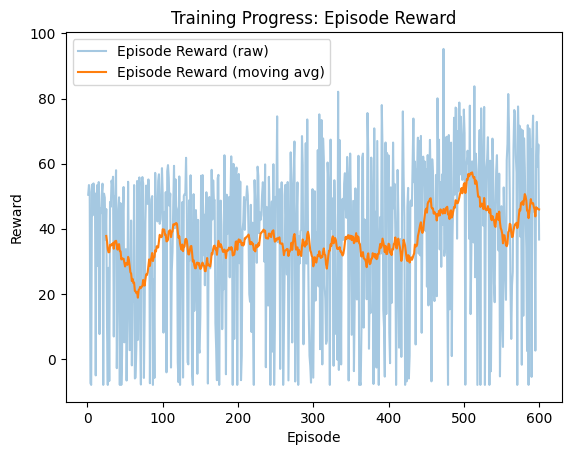

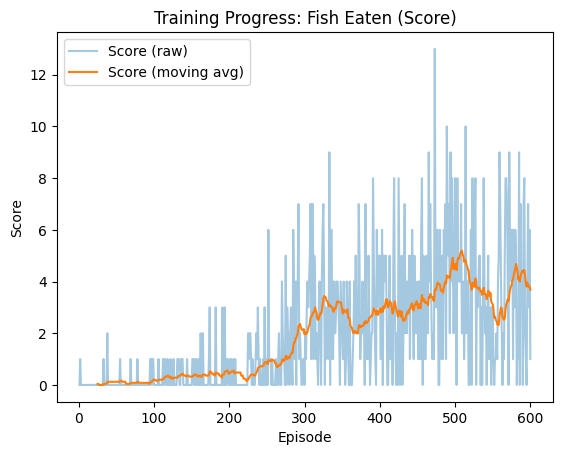

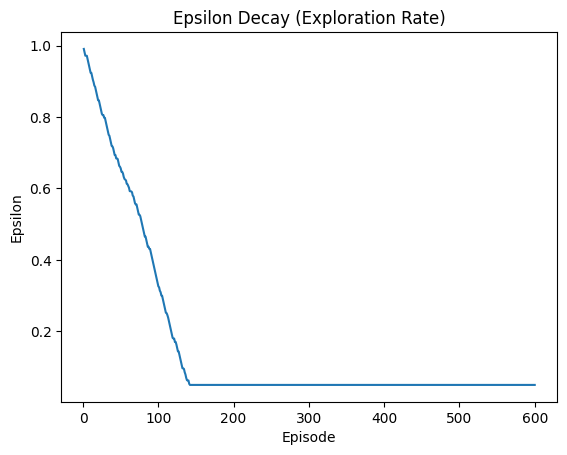

Final 10 episodes average score: 3.9
Final 10 episodes average reward: 53.35554459248188


In [45]:
# Cell 10: Performance Evaluation Plots (Improved)


import matplotlib.pyplot as plt
import numpy as np

episodes = np.array([h[0] for h in history])
ep_rewards = np.array([h[1] for h in history])
scores = np.array([h[2] for h in history])
epsilons = np.array([h[3] for h in history])

def moving_avg(x, window=20):
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window)/window, mode="valid")

# --- Reward curve ---
plt.figure()
plt.plot(episodes, ep_rewards, alpha=0.4, label="Episode Reward (raw)")
ma_r = moving_avg(ep_rewards, window=25)
plt.plot(episodes[len(episodes)-len(ma_r):], ma_r, label="Episode Reward (moving avg)")
plt.title("Training Progress: Episode Reward")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.show()

# --- Score curve ---
plt.figure()
plt.plot(episodes, scores, alpha=0.4, label="Score (raw)")
ma_s = moving_avg(scores, window=25)
plt.plot(episodes[len(episodes)-len(ma_s):], ma_s, label="Score (moving avg)")
plt.title("Training Progress: Fish Eaten (Score)")
plt.xlabel("Episode")
plt.ylabel("Score")
plt.legend()
plt.show()

# --- Epsilon curve ---
plt.figure()
plt.plot(episodes, epsilons)
plt.title("Epsilon Decay (Exploration Rate)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()

print("Final 10 episodes average score:", scores[-10:].mean())
print("Final 10 episodes average reward:", ep_rewards[-10:].mean())